# Stock Direction v6: Next-Day Directional Trading (Spec-Based)

Za?o?enia tego notebooka:
- target binarny: `UP` / `DOWN` dla kolejnej sesji,
- `no trade` wynika z progu na prawdopodobie?stwie, a nie z trzeciej klasy,
- surowe `stock_price` nie wchodzi do cech modelu,
- dane alternatywne (Reddit / Google Trends / GDELT) s? przesuni?te o 1 sesj? dla bezpiecze?stwa czasowego,
- walidacja jest czasowa, a holdout to ostatnie 2 miesi?ce.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

RANDOM_STATE = 42
TEST_MONTHS = 2
CV_FOLDS = 3
CV_VAL_SIZE = 40
CV_MIN_TRAIN = 260

LAG_STEPS = [1, 2, 3, 5]
TOP_K_CANDIDATES = [12, 20, 30, 40]
C_VALUES = [0.25, 0.5, 1.0, 2.0, 4.0]
P_THRESHOLDS = [0.52, 0.55, 0.58, 0.60]

ROLL_WINDOW = 20
ONE_WAY_COST_BPS = 5
ONE_WAY_COST = ONE_WAY_COST_BPS / 10000.0


In [2]:
def make_folds(n, n_folds=3, val_size=40, min_train=260):
    folds = []
    for i in range(n_folds):
        val_end = n - val_size * (n_folds - 1 - i)
        val_start = val_end - val_size
        if val_start < min_train:
            continue
        folds.append((np.arange(0, val_start), np.arange(val_start, val_end)))
    return folds


def add_lags(frame, feature_cols, lags):
    parts = [frame]
    for lag in lags:
        shifted = frame[feature_cols].shift(lag)
        shifted = shifted.rename(columns={c: f"{c}_lag{lag}" for c in feature_cols})
        parts.append(shifted)
    return pd.concat(parts, axis=1)


def safe_pct_change(series, periods=1):
    out = series.pct_change(periods)
    return out.replace([np.inf, -np.inf], np.nan)


def signed_log1p(series):
    return np.sign(series) * np.log1p(np.abs(series))


def rolling_zscore(series, window=20, min_periods=10):
    mean = series.rolling(window, min_periods=min_periods).mean()
    std = series.rolling(window, min_periods=min_periods).std()
    return (series - mean) / std.replace(0, np.nan)


def select_top_k_mi(X_train, y_train, k):
    imp = SimpleImputer(strategy="median")
    X_i = imp.fit_transform(X_train)
    mi = mutual_info_classif(X_i, y_train, random_state=RANDOM_STATE)
    idx = np.argsort(mi)[::-1][: min(k, len(mi))]
    return [X_train.columns[i] for i in idx]


def fit_direction_model(train_X, train_y, selected_cols, c_value):
    model = Pipeline(
        steps=[
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    C=float(c_value),
                    class_weight="balanced",
                    max_iter=3000,
                    solver="liblinear",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    model.fit(train_X[selected_cols], train_y)
    return model


def signal_from_proba(p_up, p_threshold=0.55):
    return np.where(p_up >= p_threshold, 1, np.where(p_up <= 1 - p_threshold, -1, 0)).astype(int)


def backtest_from_signals(future_returns, signals, one_way_cost):
    r = np.asarray(future_returns, dtype=float)
    s = np.asarray(signals, dtype=int)
    trade_mask = s != 0
    strat_ret = np.zeros(len(s), dtype=float)
    strat_ret[trade_mask] = s[trade_mask] * r[trade_mask] - 2.0 * one_way_cost
    true_dir = np.where(r > 0, 1.0, 0.0)
    return strat_ret, trade_mask, s, true_dir, int(trade_mask.sum())


def perf_stats(strat_ret, trade_mask, executed_signal, trades):
    strat_ret = np.asarray(strat_ret, dtype=float)
    trade_mask = np.asarray(trade_mask, dtype=bool)
    executed_signal = np.asarray(executed_signal, dtype=int)

    equity = np.cumprod(1 + strat_ret)
    running_max = np.maximum.accumulate(equity)
    drawdown = equity / running_max - 1

    n_active = int(trade_mask.sum())
    hit_rate = np.nan
    if n_active > 0:
        hit_rate = float(np.mean(strat_ret[trade_mask] > 0))

    sharpe = 0.0
    if len(strat_ret) > 1 and np.std(strat_ret, ddof=1) > 0:
        sharpe = float(np.sqrt(252) * np.mean(strat_ret) / np.std(strat_ret, ddof=1))

    return {
        "cum_return": float(equity[-1] - 1),
        "sharpe": sharpe,
        "max_drawdown": float(drawdown.min()),
        "avg_daily_return": float(np.mean(strat_ret)),
        "active_days": n_active,
        "active_pct": float(np.mean(trade_mask)),
        "entries_exits": float(int(trades) * 2),
        "hit_rate_active": hit_rate,
    }


In [3]:
data_root = next((p for p in [Path("../data/equity_data"), Path("data/equity_data")] if p.exists()), None)
if data_root is None:
    raise FileNotFoundError("Could not find data/equity_data")
model_dir = data_root / "model_data"
model_dir.mkdir(parents=True, exist_ok=True)

base_candidates = [
    model_dir / "stock_direction_dataset_v2_base_best.csv",
    model_dir / "stock_direction_dataset_base.csv",
]
base_path = next((p for p in base_candidates if p.exists()), None)
if base_path is None:
    raise FileNotFoundError("Run wcze?niejszy notebook tworz?cy bazowy dataset")

base_df = pd.read_csv(base_path)
base_df["date"] = pd.to_datetime(base_df["date"], errors="coerce")
base_df = base_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
for c in base_df.columns:
    if c != "date":
        base_df[c] = pd.to_numeric(base_df[c], errors="coerce")

if "stock_price" not in base_df.columns:
    raise ValueError("Base dataset must include stock_price")

features = pd.DataFrame({"date": base_df["date"]})
features["future_return_1d"] = base_df["stock_price"].shift(-1) / base_df["stock_price"] - 1
features["y_dir"] = np.where(
    features["future_return_1d"].isna(),
    np.nan,
    (features["future_return_1d"] > 0).astype(float),
)

features["ret_1d"] = base_df["stock_return_1d"] if "stock_return_1d" in base_df.columns else safe_pct_change(base_df["stock_price"], 1)
features["ret_2d"] = base_df["stock_return_2d"] if "stock_return_2d" in base_df.columns else safe_pct_change(base_df["stock_price"], 2)
features["ret_5d"] = base_df["stock_return_5d"] if "stock_return_5d" in base_df.columns else safe_pct_change(base_df["stock_price"], 5)
features["ret_10d"] = base_df["stock_return_10d"] if "stock_return_10d" in base_df.columns else safe_pct_change(base_df["stock_price"], 10)
features["volume_change_1d"] = base_df["stock_volume_change_1d"] if "stock_volume_change_1d" in base_df.columns else safe_pct_change(base_df["stock_volume"], 1)
features["volume_change_5d"] = base_df["stock_volume_change_5d"] if "stock_volume_change_5d" in base_df.columns else safe_pct_change(base_df["stock_volume"], 5)
features["realized_vol_5d"] = base_df["realized_vol_5d"] if "realized_vol_5d" in base_df.columns else features["ret_1d"].rolling(5).std()
features["realized_vol_10d"] = base_df["realized_vol_10d"] if "realized_vol_10d" in base_df.columns else features["ret_1d"].rolling(10).std()
features["price_vs_sma_5d"] = base_df["price_vs_sma_5d"] if "price_vs_sma_5d" in base_df.columns else base_df["stock_price"] / base_df["stock_price"].rolling(5).mean() - 1
features["price_vs_sma_10d"] = base_df["price_vs_sma_10d"] if "price_vs_sma_10d" in base_df.columns else base_df["stock_price"] / base_df["stock_price"].rolling(10).mean() - 1

log_volume = np.log1p(base_df["stock_volume"].clip(lower=0)) if "stock_volume" in base_df.columns else pd.Series(np.nan, index=base_df.index)
volume_sma20 = base_df["stock_volume"].rolling(ROLL_WINDOW, min_periods=10).mean() if "stock_volume" in base_df.columns else pd.Series(np.nan, index=base_df.index)
features["volume_z20"] = rolling_zscore(log_volume, ROLL_WINDOW)
features["volume_vs_sma_20d"] = base_df["stock_volume"] / volume_sma20 - 1 if "stock_volume" in base_df.columns else pd.Series(np.nan, index=base_df.index)

weekday = base_df["weekday"] if "weekday" in base_df.columns else base_df["date"].dt.dayofweek.astype(float)
features["weekday_sin"] = np.sin(2 * np.pi * weekday / 5.0)
features["weekday_cos"] = np.cos(2 * np.pi * weekday / 5.0)

def shifted_series(name, fill=None):
    if name not in base_df.columns:
        return pd.Series(np.nan, index=base_df.index, dtype="float64")
    s = base_df[name].shift(1)
    if fill == "ffill":
        s = s.ffill()
    elif fill == "zero":
        s = s.fillna(0.0)
    return s

trends_level = shifted_series("google_trends_score", fill="ffill")
if trends_level.notna().any():
    features["trends_level_z20"] = rolling_zscore(trends_level, ROLL_WINDOW)
    features["trends_change_1d"] = safe_pct_change(trends_level, 1).clip(-1.0, 1.0)
    features["trends_change_7d"] = safe_pct_change(trends_level, 7).clip(-1.0, 1.0)

gdelt_articles = shifted_series("gdelt_articles", fill="ffill")
if gdelt_articles.notna().any():
    log_articles = np.log1p(gdelt_articles.clip(lower=0))
    features["gdelt_articles_log"] = log_articles
    features["gdelt_articles_z20"] = rolling_zscore(log_articles, ROLL_WINDOW)
    features["gdelt_articles_change_1d"] = safe_pct_change(gdelt_articles, 1).clip(-3.0, 3.0)

gdelt_sentiment = shifted_series("gdelt_sentiment_score", fill="ffill")
if gdelt_sentiment.notna().any():
    features["gdelt_sentiment_score"] = gdelt_sentiment
    features["gdelt_sentiment_5d"] = gdelt_sentiment.rolling(5, min_periods=3).mean()

def add_reddit_block(prefix):
    posts_col = f"{prefix}reddit_posts"
    score_col = f"{prefix}reddit_score_sum"
    comments_col = f"{prefix}reddit_comments_sum"
    vader_col = f"{prefix}reddit_vader_weighted_mean" if f"{prefix}reddit_vader_weighted_mean" in base_df.columns else f"{prefix}reddit_vader_mean"
    finbert_col = f"{prefix}reddit_finbert_weighted_mean" if f"{prefix}reddit_finbert_weighted_mean" in base_df.columns else f"{prefix}reddit_finbert_mean"
    gap_col = f"{prefix}sent_gap_mean"

    posts = shifted_series(posts_col, fill="zero")
    if posts_col in base_df.columns:
        log_posts = np.log1p(posts.clip(lower=0))
        features[f"{prefix}log_posts"] = log_posts
        features[f"{prefix}posts_z20"] = rolling_zscore(log_posts, ROLL_WINDOW)
        features[f"{prefix}active_flag"] = (posts > 0).astype(float)

    if score_col in base_df.columns:
        score = shifted_series(score_col, fill="zero")
        features[f"{prefix}score_signed_log"] = signed_log1p(score)

    if comments_col in base_df.columns:
        comments = shifted_series(comments_col, fill="zero")
        if comments.nunique(dropna=True) > 1:
            features[f"{prefix}log_comments_sum"] = np.log1p(comments.clip(lower=0))

    if vader_col in base_df.columns:
        features[f"{prefix}vader_mean"] = shifted_series(vader_col, fill="zero")

    if finbert_col in base_df.columns:
        features[f"{prefix}finbert_mean"] = shifted_series(finbert_col, fill="zero")

    if gap_col in base_df.columns:
        features[f"{prefix}sent_gap_mean"] = shifted_series(gap_col, fill="zero")

add_reddit_block("subm_")
add_reddit_block("comm_")

candidate_cols = [c for c in features.columns if c not in ["date", "future_return_1d", "y_dir"]]
constant_cols = [c for c in candidate_cols if features[c].nunique(dropna=True) <= 1]
if constant_cols:
    features = features.drop(columns=constant_cols)

base_features = [c for c in features.columns if c not in ["date", "future_return_1d", "y_dir"]]

print(f"Base source: {base_path}")
print(f"Rows: {len(features):,}")
print(f"Engineered base features: {len(base_features)}")
print(f"Removed constant columns: {constant_cols}")
display(features.head())


Base source: ..\data\equity_data\model_data\stock_direction_dataset_v2_base_best.csv
Rows: 751
Engineered base features: 37
Removed constant columns: []


,date,future_return_1d,y_dir,ret_1d,ret_2d,ret_5d,ret_10d,volume_change_1d,volume_change_5d,realized_vol_5d,...,subm_vader_mean,subm_finbert_mean,subm_sent_gap_mean,comm_log_posts,comm_posts_z20,comm_active_flag,comm_score_signed_log,comm_vader_mean,comm_finbert_mean,comm_sent_gap_mean
0,2023-01-03,0.051249,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,0.0,0.000000,0.000000,0.000000,0.000000
1,2023-01-04,-0.029039,0.0,0.051249,NaN,NaN,NaN,-0.220455,NaN,NaN,...,0.305369,-0.175264,0.422904,6.118097,NaN,1.0,7.609367,0.187674,-0.137697,0.315346
2,2023-01-05,0.024651,1.0,-0.029039,0.020722,NaN,NaN,-0.124191,NaN,NaN,...,0.596288,-0.384605,1.015222,5.117994,NaN,1.0,6.976348,0.133119,-0.107439,0.281207
3,2023-01-06,0.059349,1.0,0.024651,-0.005104,NaN,NaN,0.398293,NaN,NaN,...,0.258447,-0.780263,0.734666,4.262680,NaN,1.0,7.568896,0.126862,-0.062067,0.229124
4,2023-01-09,-0.007681,0.0,0.059349,0.085463,NaN,NaN,-0.138640,NaN,NaN,...,-0.486909,-0.822936,0.742524,4.219508,NaN,1.0,6.317165,0.279178,-0.245605,0.473386


In [4]:
base_out_path = model_dir / "stock_direction_dataset_v6_base.csv"
features.to_csv(base_out_path, index=False)

core = features[["date", "future_return_1d", "y_dir"] + base_features].copy()
lagged_df = add_lags(core, base_features, LAG_STEPS)
lagged_df = lagged_df.dropna(subset=["future_return_1d", "y_dir"]).reset_index(drop=True)
model_features = [c for c in lagged_df.columns if c not in ["date", "future_return_1d", "y_dir"]]

lagged_out_path = model_dir / "stock_direction_dataset_v6_lagged.csv"
lagged_df.to_csv(lagged_out_path, index=False)

test_start = (lagged_df["date"].max() - pd.DateOffset(months=TEST_MONTHS)).normalize()
train_df = lagged_df[lagged_df["date"] < test_start].copy()
test_df = lagged_df[lagged_df["date"] >= test_start].copy()
if train_df.empty or test_df.empty:
    raise ValueError("Train/test split is empty. Check date range or TEST_MONTHS.")

train_target = train_df["y_dir"].astype(int)
test_target = test_df["y_dir"].astype(int)
dist = pd.DataFrame({
    "train_pct": (train_target.value_counts(normalize=True) * 100).reindex([0, 1]).fillna(0).round(2),
    "test_pct": (test_target.value_counts(normalize=True) * 100).reindex([0, 1]).fillna(0).round(2),
}, index=["spadek", "wzrost"])

print(f"Data graniczna testu: {test_start.date()}")
print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Model features (with lags): {len(model_features):,}")
print(base_out_path)
print(lagged_out_path)
display(dist)


Data graniczna testu: 2025-10-29
Train rows: 708
Test rows: 42
Model features (with lags): 185
..\data\equity_data\model_data\stock_direction_dataset_v6_base.csv
..\data\equity_data\model_data\stock_direction_dataset_v6_lagged.csv


,train_pct,test_pct
spadek,NaN,NaN
wzrost,NaN,NaN


In [5]:
folds = make_folds(len(train_df), CV_FOLDS, CV_VAL_SIZE, CV_MIN_TRAIN)
if not folds:
    raise RuntimeError("Could not create walk-forward folds")

search_rows = []
for top_k in TOP_K_CANDIDATES:
    for c_val in C_VALUES:
        for p_thr in P_THRESHOLDS:
            fold_stats = []
            for tr_idx, va_idx in folds:
                tr = train_df.iloc[tr_idx]
                va = train_df.iloc[va_idx]

                y_tr = tr["y_dir"].to_numpy(dtype=int)
                cols = select_top_k_mi(tr[model_features], y_tr, top_k)
                model = fit_direction_model(tr, y_tr, cols, c_val)

                p_up_va = model.predict_proba(va[cols])[:, 1]
                sig_va = signal_from_proba(p_up_va, p_threshold=p_thr)
                ret_va, mask_va, sig_exec_va, true_dir_va, n_trades_va = backtest_from_signals(
                    va["future_return_1d"].to_numpy(),
                    sig_va,
                    ONE_WAY_COST,
                )
                fold_stats.append(perf_stats(ret_va, mask_va, sig_exec_va, n_trades_va))

            cv_cum = float(np.mean([s["cum_return"] for s in fold_stats]))
            cv_sharpe = float(np.mean([s["sharpe"] for s in fold_stats]))
            cv_active = float(np.mean([s["active_pct"] for s in fold_stats]))
            hit_values = [s["hit_rate_active"] for s in fold_stats if not np.isnan(s["hit_rate_active"])]
            cv_hit = float(np.mean(hit_values)) if hit_values else 0.5

            score = 0.45 * cv_sharpe + 0.35 * cv_cum + 0.20 * (cv_hit - 0.5)
            if cv_active < 0.05:
                score -= 0.25

            search_rows.append({
                "top_k": top_k,
                "c_value": c_val,
                "p_threshold": p_thr,
                "cv_score": score,
                "cv_cum_return": cv_cum,
                "cv_sharpe": cv_sharpe,
                "cv_active_pct": cv_active,
                "cv_hit_rate": cv_hit,
                "train_rows": len(train_df),
                "test_rows": len(test_df),
                "test_start": str(test_start.date()),
            })

search_df = pd.DataFrame(search_rows).sort_values("cv_score", ascending=False).reset_index(drop=True)
if search_df.empty:
    raise RuntimeError("No search results generated")

display(search_df.head(10))
best_cfg = search_df.iloc[0].to_dict()
print("Best config:", best_cfg)


,top_k,c_value,p_threshold,cv_score,cv_cum_return,cv_sharpe,cv_active_pct,cv_hit_rate,train_rows,test_rows,test_start
0,20,2.00,0.58,1.111774,0.206327,2.268145,0.525000,0.594474,708,42,2025-10-29
1,20,4.00,0.58,1.111774,0.206327,2.268145,0.525000,0.594474,708,42,2025-10-29
2,20,4.00,0.60,1.087308,0.195481,2.215991,0.441667,0.608466,708,42,2025-10-29
3,20,1.00,0.58,1.052130,0.200281,2.142871,0.516667,0.588702,708,42,2025-10-29
4,20,0.50,0.60,1.047565,0.174788,2.145689,0.416667,0.604148,708,42,2025-10-29
5,20,0.25,0.58,1.036999,0.187704,2.115241,0.508333,0.597222,708,42,2025-10-29
6,20,1.00,0.60,1.034641,0.188065,2.107896,0.433333,0.601323,708,42,2025-10-29
7,20,2.00,0.60,1.034641,0.188065,2.107896,0.433333,0.601323,708,42,2025-10-29
8,20,0.50,0.58,1.027410,0.186915,2.099034,0.516667,0.587121,708,42,2025-10-29
9,20,0.25,0.60,1.025636,0.172810,2.101764,0.408333,0.596795,708,42,2025-10-29


Best config: {'top_k': 20, 'c_value': 2.0, 'p_threshold': 0.58, 'cv_score': 1.111774310736566, 'cv_cum_return': 0.20632688477353303, 'cv_sharpe': 2.2681446009028736, 'cv_active_pct': 0.525, 'cv_hit_rate': 0.5944741532976827, 'train_rows': 708, 'test_rows': 42, 'test_start': '2025-10-29'}


,model,split,cum_return,sharpe,max_drawdown,avg_daily_return,active_days,active_pct,entries_exits,hit_rate_active
0,BuyHold,train,1.1044,0.7359,-0.6007,0.0018,708,1.0000,1416.0,0.5113
1,BuyHold,test,-0.0559,-0.5114,-0.1768,-0.0009,42,1.0000,84.0,0.5000
2,Directional_v6,train,15.0716,2.6566,-0.2036,0.0042,310,0.4379,620.0,0.6323
3,Directional_v6,test,0.0646,1.4251,-0.0642,0.0017,18,0.4286,36.0,0.5000


Best setup -> top_k=20, C=2.0, p_threshold=0.58
Costs: 5 bps one-way
Raport kierunku na aktywnych transakcjach (long=1, short=0):
              precision    recall  f1-score   support

           0       0.62      0.80      0.70        10
           1       0.60      0.38      0.46         8

    accuracy                           0.61        18
   macro avg       0.61      0.59      0.58        18
weighted avg       0.61      0.61      0.59        18



,feature,coef,abs_coef
0,volume_vs_sma_20d,0.383750,0.383750
1,realized_vol_5d_lag3,-0.265751,0.265751
2,subm_finbert_mean_lag5,0.260492,0.260492
3,realized_vol_10d_lag5,0.198897,0.198897
4,gdelt_articles_log_lag2,-0.139420,0.139420
5,gdelt_sentiment_score,-0.135888,0.135888
6,volume_change_1d,-0.114913,0.114913
7,gdelt_sentiment_score_lag5,0.102909,0.102909
8,realized_vol_5d_lag2,0.097570,0.097570
9,trends_change_7d_lag3,0.094035,0.094035


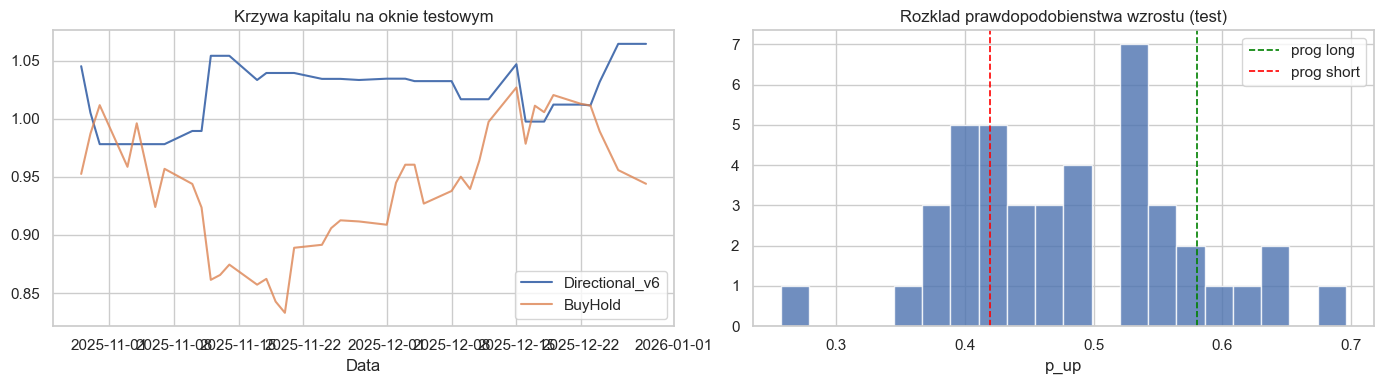

..\data\equity_data\model_data\stock_direction_v6_search_results.csv
..\data\equity_data\model_data\stock_direction_v6_metrics.csv
..\data\equity_data\model_data\stock_direction_v6_test_predictions.csv
..\data\equity_data\model_data\stock_direction_v6_selected_features.csv


In [6]:
top_k = int(best_cfg["top_k"])
c_val = float(best_cfg["c_value"])
p_thr = float(best_cfg["p_threshold"])

y_train = train_df["y_dir"].to_numpy(dtype=int)
y_test = test_df["y_dir"].to_numpy(dtype=int)

sel_cols = select_top_k_mi(train_df[model_features], y_train, top_k)
model = fit_direction_model(train_df, y_train, sel_cols, c_val)

p_up_train = model.predict_proba(train_df[sel_cols])[:, 1]
p_up_test = model.predict_proba(test_df[sel_cols])[:, 1]

sig_train = signal_from_proba(p_up_train, p_threshold=p_thr)
sig_test = signal_from_proba(p_up_test, p_threshold=p_thr)

ret_train, mask_train, sig_exec_train, true_dir_train, n_trades_train = backtest_from_signals(
    train_df["future_return_1d"].to_numpy(),
    sig_train,
    ONE_WAY_COST,
)
ret_test, mask_test, sig_exec_test, true_dir_test, n_trades_test = backtest_from_signals(
    test_df["future_return_1d"].to_numpy(),
    sig_test,
    ONE_WAY_COST,
)

stats_train = perf_stats(ret_train, mask_train, sig_exec_train, n_trades_train)
stats_test = perf_stats(ret_test, mask_test, sig_exec_test, n_trades_test)

bh_sig_train = np.ones(len(train_df), dtype=int)
bh_sig_test = np.ones(len(test_df), dtype=int)
bh_train, bh_mask_train, bh_exec_train, bh_true_train, bh_ntr_train = backtest_from_signals(
    train_df["future_return_1d"].to_numpy(),
    bh_sig_train,
    ONE_WAY_COST,
)
bh_test, bh_mask_test, bh_exec_test, bh_true_test, bh_ntr_test = backtest_from_signals(
    test_df["future_return_1d"].to_numpy(),
    bh_sig_test,
    ONE_WAY_COST,
)
bh_stats_train = perf_stats(bh_train, bh_mask_train, bh_exec_train, bh_ntr_train)
bh_stats_test = perf_stats(bh_test, bh_mask_test, bh_exec_test, bh_ntr_test)

metrics_df = pd.DataFrame(
    [
        {"model": "BuyHold", "split": "train", **bh_stats_train},
        {"model": "BuyHold", "split": "test", **bh_stats_test},
        {"model": "Directional_v6", "split": "train", **stats_train},
        {"model": "Directional_v6", "split": "test", **stats_test},
    ]
)
display(metrics_df.round(4))

print(f"Best setup -> top_k={top_k}, C={c_val}, p_threshold={p_thr}")
print(f"Costs: {ONE_WAY_COST_BPS} bps one-way")

active_mask = mask_test
if active_mask.any():
    active_true = true_dir_test[active_mask].astype(int)
    active_pred = (sig_exec_test[active_mask] > 0).astype(int)
    print("Raport kierunku na aktywnych transakcjach (long=1, short=0):")
    print(classification_report(active_true, active_pred, zero_division=0))
else:
    print("Brak aktywnych transakcji na zbiorze testowym.")

coef = model.named_steps["clf"].coef_.ravel()
features_df = pd.DataFrame({
    "feature": sel_cols,
    "coef": coef,
    "abs_coef": np.abs(coef),
}).sort_values("abs_coef", ascending=False).reset_index(drop=True)
display(features_df.head(20))

eq_strat = np.cumprod(1 + ret_test)
eq_bh = np.cumprod(1 + bh_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(test_df["date"], eq_strat, label="Directional_v6")
axes[0].plot(test_df["date"], eq_bh, label="BuyHold", alpha=0.8)
axes[0].set_title("Krzywa kapitalu na oknie testowym")
axes[0].set_xlabel("Data")
axes[0].legend()

axes[1].hist(p_up_test, bins=20, alpha=0.8)
axes[1].axvline(p_thr, color="green", linestyle="--", linewidth=1.2, label="prog long")
axes[1].axvline(1 - p_thr, color="red", linestyle="--", linewidth=1.2, label="prog short")
axes[1].set_title("Rozklad prawdopodobienstwa wzrostu (test)")
axes[1].set_xlabel("p_up")
axes[1].legend()
plt.tight_layout()
plt.show()

preds_df = pd.DataFrame({
    "date": test_df["date"].values,
    "future_return_1d": test_df["future_return_1d"].values,
    "y_true": y_test,
    "p_up": p_up_test,
    "signal_raw": sig_test,
    "signal_executed": sig_exec_test,
    "trade_executed": mask_test,
    "strategy_return": ret_test,
    "trade_true_dir": true_dir_test,
})

search_path = model_dir / "stock_direction_v6_search_results.csv"
metrics_path = model_dir / "stock_direction_v6_metrics.csv"
preds_path = model_dir / "stock_direction_v6_test_predictions.csv"
features_path = model_dir / "stock_direction_v6_selected_features.csv"

search_df.to_csv(search_path, index=False)
metrics_df.to_csv(metrics_path, index=False)
preds_df.to_csv(preds_path, index=False)
features_df.to_csv(features_path, index=False)

print(search_path)
print(metrics_path)
print(preds_path)
print(features_path)
